# Pupil Function → PSF：用 BioBeam 实际模拟验证

## 目标

用 BioBeam 里实际的 `focus_field_*` 函数（基于矢量 Debye-Wolf 积分）计算 3D PSF，
然后验证：焦平面（z=0）的 xy 截面，是否和手写瞳面函数做 2D FT 的结果一致。

$$h_{\text{BioBeam}}(x,y,z=0) \stackrel{?}{=} |\mathcal{F}\{P(k_x,k_y)\}|^2$$

覆盖四种照明模式：
- **DSLM**：高斯光束（实心圆盘瞳面）
- **Bessel**：环形瞳面
- **SPIM**：圆柱镜（1D 瞳面）
- **Lattice Light-Sheet**：环上离散点瞳面

In [1]:
import numpy as np
import matplotlib.pyplot as plt

# BioBeam 实际的焦场计算函数
from biobeam.core.focus_field_beam import focus_field_beam
from biobeam.core.focus_field_cylindrical import focus_field_cylindrical
from biobeam.core.focus_field_lattice import focus_field_lattice

plt.rcParams['figure.dpi'] = 120

d:\Applications\Anaconda3\lib\site-packages\pyopencl\__init__.py:270: CompilerWarning: Non-empty compiler output encountered. Set the environment variable PYOPENCL_COMPILER_OUTPUT=1 to see more.
  warn("Non-empty compiler output encountered. Set the "


If you want to compute separable approximations, please install it with
pip install scikit-tensor-py3


## Step 1：用 BioBeam 计算四种实际 3D PSF

`focus_field_beam / cylindrical / lattice` 内部调用 OpenCL kernel（`psf_debye.cl` 等），
通过 Debye-Wolf 矢量积分直接在 GPU 上计算完整的 3D 焦场强度分布。

In [2]:
shape = (128, 128, 128)   # Nx, Ny, Nz
units = (0.05, 0.05, 0.05) # dx, dy, dz in microns
lam   = 0.488              # 激发波长 (microns)
n0    = 1.0                # 折射率

print("计算 DSLM (高斯光束, NA=0.3)...")
u_dslm = focus_field_beam(shape, units, lam=lam, NA=0.3, n0=n0)

print("计算 Bessel (环形孔径, NA=[0.42, 0.50])...")
u_bessel = focus_field_beam(shape, units, lam=lam, NA=[0.42, 0.50], n0=n0)

print("计算 SPIM (圆柱镜, NA=0.1)...")
u_spim = focus_field_cylindrical(shape, units, lam=lam, NA=0.1, n0=n0)

print("计算 Lattice (NA1=0.44, NA2=0.55, 6 points)...")
u_lattice = focus_field_lattice(shape, units, lam=lam, NA1=0.44, NA2=0.55,
                                sigma=0.1, kpoints=6, n0=n0)

print("完成！")
print(f"每个 PSF 的 shape: {u_dslm.shape}  (Nz, Ny, Nx)")

计算 DSLM (高斯光束, NA=0.3)...


d:\Applications\Anaconda3\lib\site-packages\pyopencl\__init__.py:270: CompilerWarning: Non-empty compiler output encountered. Set the environment variable PYOPENCL_COMPILER_OUTPUT=1 to see more.
  warn("Non-empty compiler output encountered. Set the "


计算 Bessel (环形孔径, NA=[0.42, 0.50])...
计算 SPIM (圆柱镜, NA=0.1)...
time in secs: 0.20545148849487305
计算 Lattice (NA1=0.44, NA2=0.55, 6 points)...
完成！
每个 PSF 的 shape: (128, 128, 128)  (Nz, Ny, Nx)


## Step 2：可视化 BioBeam 的 3D PSF（xz 和 xy 截面）

对比 Figure 8 的第2、3列：xz 截面展示光片形状，xy 截面展示焦平面强度。

C:\Users\gravitychen\AppData\Local\Temp\ipykernel_25564\1537064211.py:34: UserWarning: Glyph 39640 (\N{CJK UNIFIED IDEOGRAPH-9AD8}) missing from current font.
  plt.tight_layout()
C:\Users\gravitychen\AppData\Local\Temp\ipykernel_25564\1537064211.py:34: UserWarning: Glyph 26031 (\N{CJK UNIFIED IDEOGRAPH-65AF}) missing from current font.
  plt.tight_layout()
C:\Users\gravitychen\AppData\Local\Temp\ipykernel_25564\1537064211.py:34: UserWarning: Glyph 25130 (\N{CJK UNIFIED IDEOGRAPH-622A}) missing from current font.
  plt.tight_layout()
C:\Users\gravitychen\AppData\Local\Temp\ipykernel_25564\1537064211.py:34: UserWarning: Glyph 38754 (\N{CJK UNIFIED IDEOGRAPH-9762}) missing from current font.
  plt.tight_layout()
C:\Users\gravitychen\AppData\Local\Temp\ipykernel_25564\1537064211.py:34: UserWarning: Glyph 28966 (\N{CJK UNIFIED IDEOGRAPH-7126}) missing from current font.
  plt.tight_layout()
C:\Users\gravitychen\AppData\Local\Temp\ipykernel_25564\1537064211.py:34: UserWarning: Glyph 24179 (

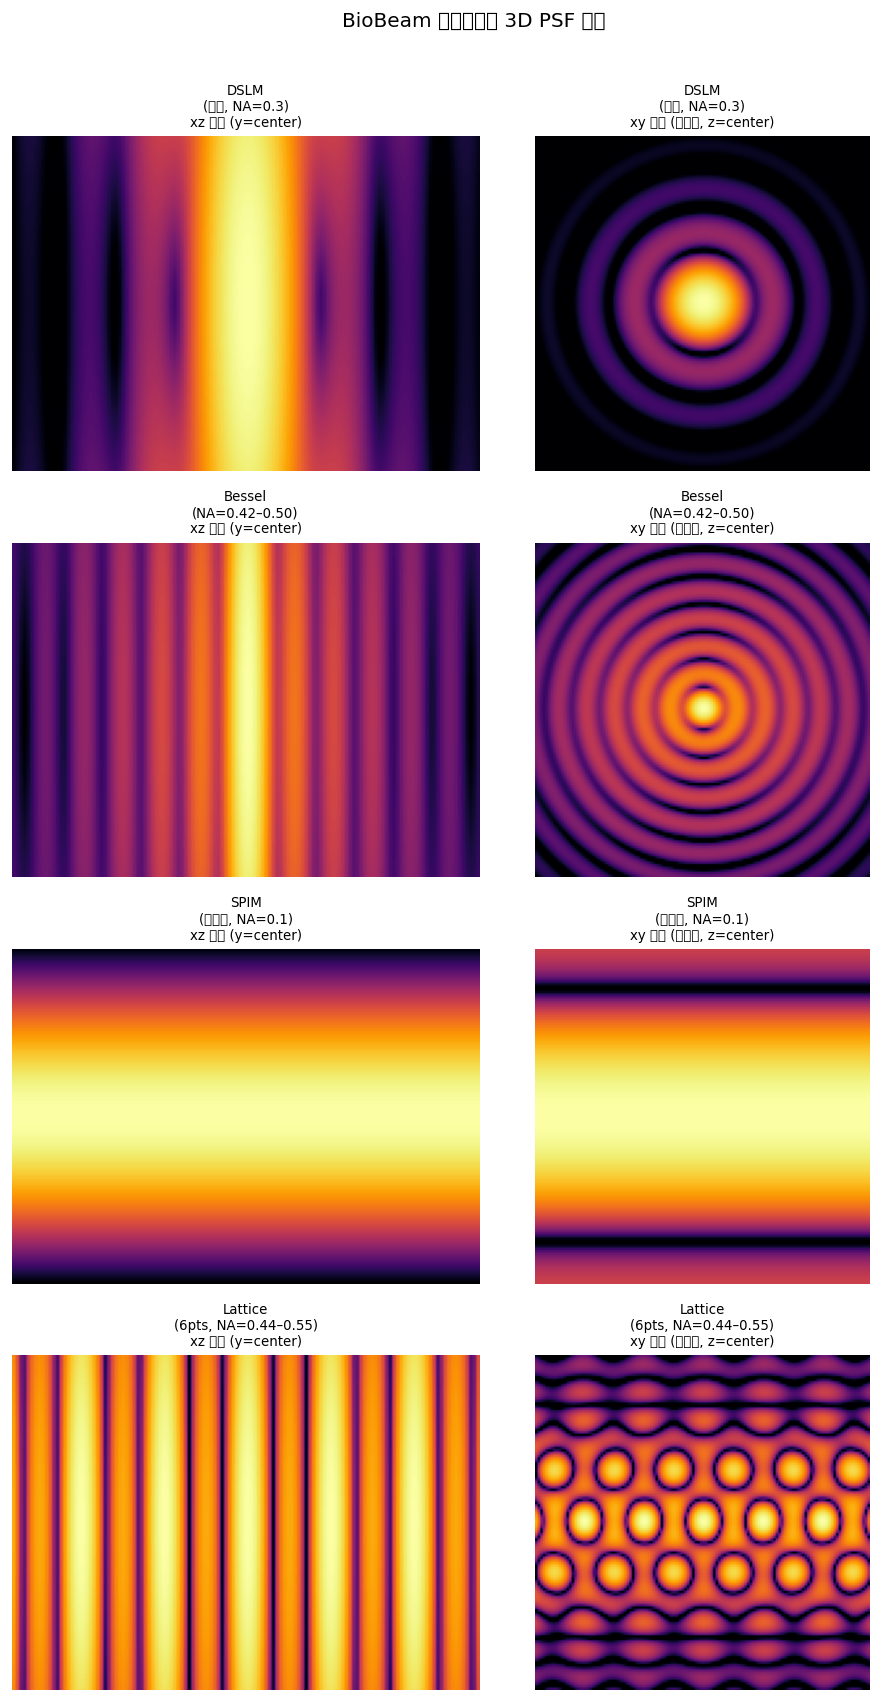

In [3]:
def log_clip(img, decades=3):
    """对数压缩，方便显示旁瓣"""
    eps = img.max() * 1e-10
    return np.clip(np.log10(img + eps), np.log10(img.max()) - decades, np.log10(img.max()))

configs = [
    ("DSLM\n(高斯, NA=0.3)",        u_dslm),
    ("Bessel\n(NA=0.42–0.50)",      u_bessel),
    ("SPIM\n(圆柱镜, NA=0.1)",      u_spim),
    ("Lattice\n(6pts, NA=0.44–0.55)", u_lattice),
]

fig, axes = plt.subplots(len(configs), 2, figsize=(8, 3.5 * len(configs)))
fig.suptitle("BioBeam 实际计算的 3D PSF 截面", fontsize=12, y=1.01)

Nz, Ny, Nx = u_dslm.shape
cz, cy, cx = Nz//2, Ny//2, Nx//2

for row, (label, u) in enumerate(configs):
    # xz 截面（光片传播方向剖面，取 y 中心）
    xz = u[:, cy, :]          # shape: (Nz, Nx)
    # xy 截面（焦平面，取 z 中心）
    xy = u[cz, :, :]          # shape: (Ny, Nx)

    axes[row, 0].imshow(log_clip(xz), cmap='inferno', origin='lower',
                        aspect='auto')
    axes[row, 0].set_title(f"{label}\nxz 截面 (y=center)", fontsize=8)
    axes[row, 0].axis('off')

    axes[row, 1].imshow(log_clip(xy), cmap='inferno', origin='lower')
    axes[row, 1].set_title(f"{label}\nxy 截面 (焦平面, z=center)", fontsize=8)
    axes[row, 1].axis('off')

plt.tight_layout()
plt.savefig("biobeam_psf_slices.png", dpi=150, bbox_inches='tight')
plt.show()

## Step 3：定义对应的理论瞳面函数

这里的瞳面函数和 BioBeam 内部 OpenCL kernel 使用的一致：
- DSLM: `KR <= NA`
- Bessel: `NA1 <= KR <= NA2`
- SPIM: `|KY| < eps`（圆柱镜 = 1D 线）
- Lattice: 环上 N 个高斯模糊点

In [4]:
N = 512
kmax = 1.0
k = np.linspace(-kmax, kmax, N)
KX, KY = np.meshgrid(k, k)
KR  = np.sqrt(KX**2 + KY**2)
PHI = np.arctan2(KY, KX)

# DSLM
P_dslm = (KR <= 0.3).astype(float)

# Bessel
P_bessel = ((KR >= 0.42) & (KR <= 0.50)).astype(float)

# SPIM 圆柱镜：水平线（ky ≈ 0，kx 在 NA 范围内）
line_hw = 0.015
P_spim = ((np.abs(KY) < line_hw) & (KR <= 0.1)).astype(float)

# Lattice
NA1_lat, NA2_lat = 0.44, 0.55
sigma_phi = 0.15
N_pts = 6
ring_mask = (KR >= NA1_lat) & (KR <= NA2_lat)
phi_pts = np.pi/2 + 2*np.pi/N_pts * np.arange(N_pts)
P_lattice = np.zeros((N, N))
for phi_i in phi_pts:
    dphi = (PHI - phi_i + np.pi) % (2*np.pi) - np.pi
    P_lattice += np.exp(-dphi**2 / (2*sigma_phi**2))
P_lattice *= ring_mask
P_lattice /= P_lattice.max()

print("瞳面函数定义完毕")

瞳面函数定义完毕


## Step 4：核心验证 —— BioBeam 焦平面 vs FT{P} 对比

如果 $h(x,y,z=0) = |\mathcal{F}\{P\}|^2$ 成立，两列图应该形状一致。

C:\Users\gravitychen\AppData\Local\Temp\ipykernel_25564\2679191296.py:51: UserWarning: Glyph 29702 (\N{CJK UNIFIED IDEOGRAPH-7406}) missing from current font.
  plt.tight_layout()
C:\Users\gravitychen\AppData\Local\Temp\ipykernel_25564\2679191296.py:51: UserWarning: Glyph 35770 (\N{CJK UNIFIED IDEOGRAPH-8BBA}) missing from current font.
  plt.tight_layout()
C:\Users\gravitychen\AppData\Local\Temp\ipykernel_25564\2679191296.py:51: UserWarning: Glyph 26631 (\N{CJK UNIFIED IDEOGRAPH-6807}) missing from current font.
  plt.tight_layout()
C:\Users\gravitychen\AppData\Local\Temp\ipykernel_25564\2679191296.py:51: UserWarning: Glyph 37327 (\N{CJK UNIFIED IDEOGRAPH-91CF}) missing from current font.
  plt.tight_layout()
C:\Users\gravitychen\AppData\Local\Temp\ipykernel_25564\2679191296.py:51: UserWarning: Glyph 28966 (\N{CJK UNIFIED IDEOGRAPH-7126}) missing from current font.
  plt.tight_layout()
C:\Users\gravitychen\AppData\Local\Temp\ipykernel_25564\2679191296.py:51: UserWarning: Glyph 24179 (

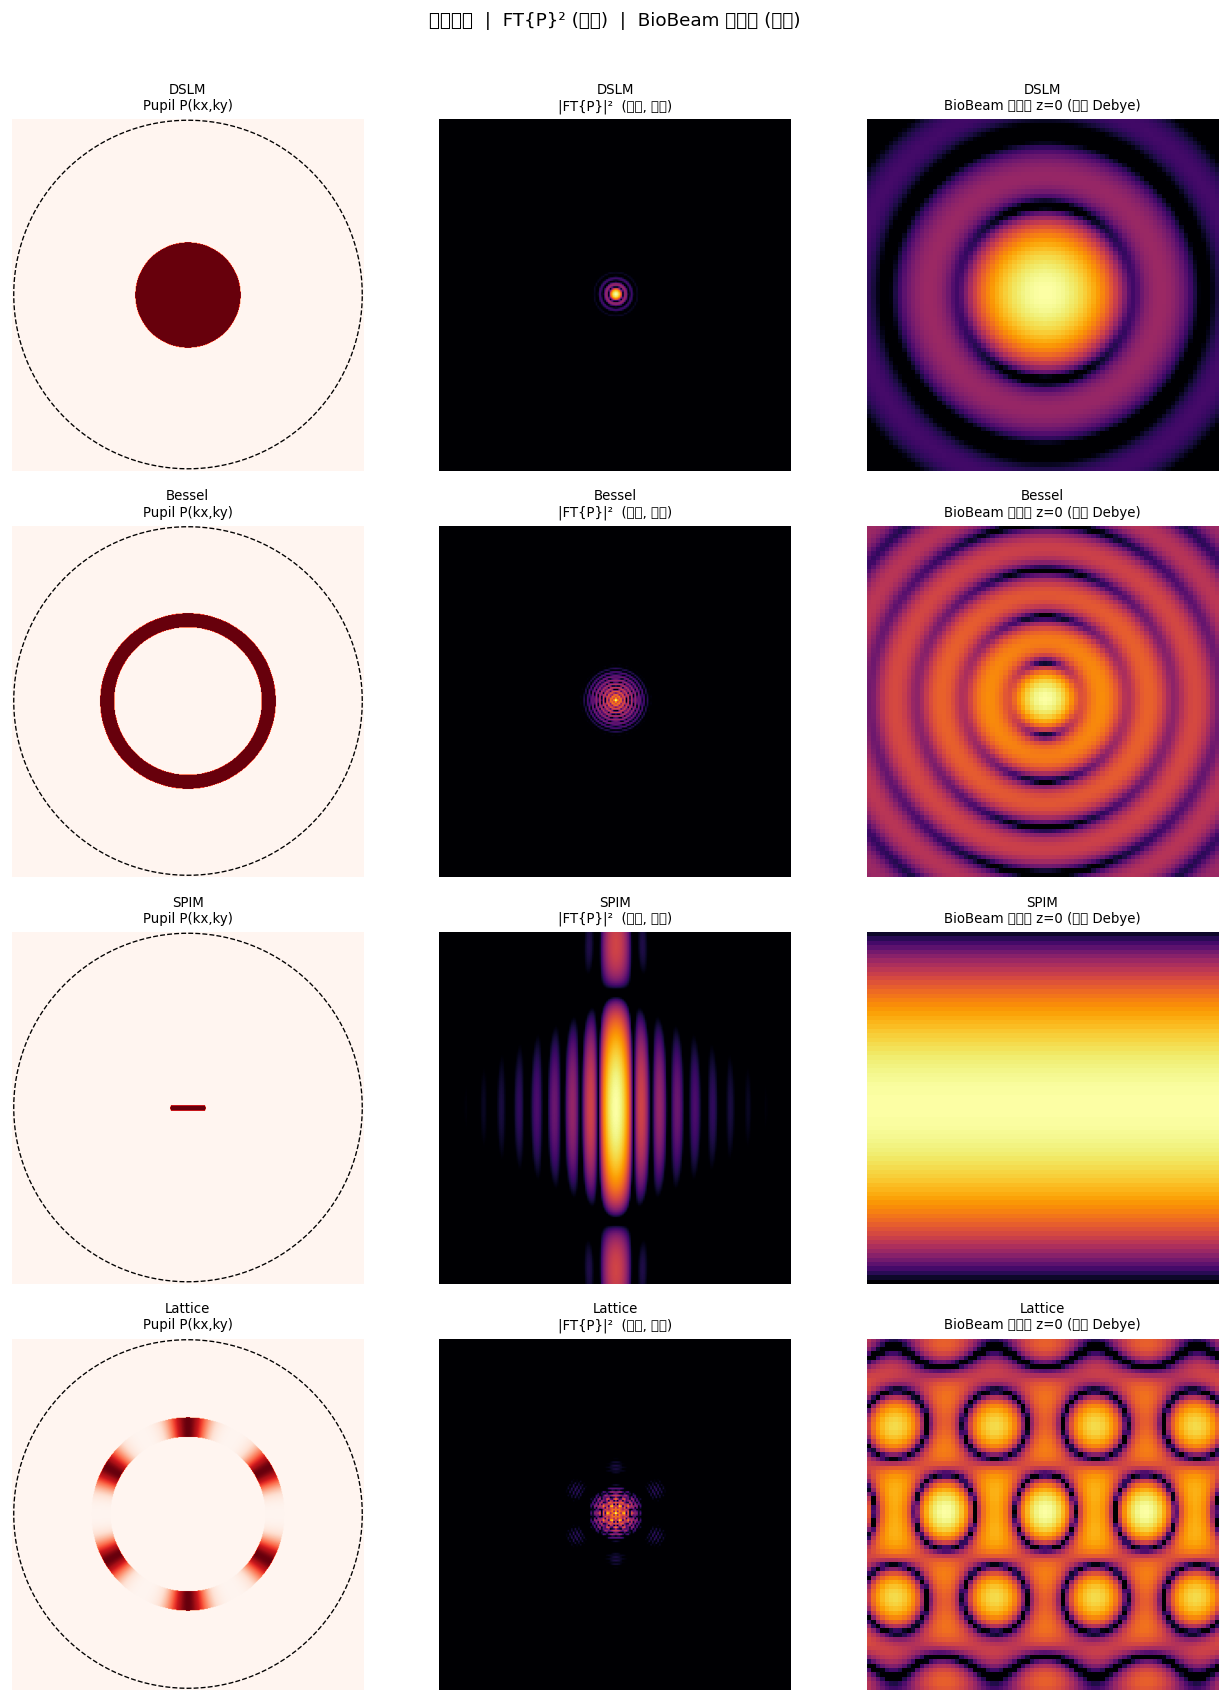

In [5]:
def pupil_to_psf(P):
    E = np.fft.fftshift(np.fft.fft2(np.fft.ifftshift(P)))
    return np.abs(E)**2

def show_pupil(ax, P, title):
    ax.imshow(P, cmap='Reds', origin='lower')
    # 画最大 NA 虚线圆
    theta = np.linspace(0, 2*np.pi, 300)
    r = N//2 - 2
    ax.plot(N//2 + r*np.cos(theta), N//2 + r*np.sin(theta), 'k--', lw=0.8)
    ax.set_title(title, fontsize=8)
    ax.axis('off')

psf_configs = [
    ("DSLM",    P_dslm,    u_dslm),
    ("Bessel",  P_bessel,  u_bessel),
    ("SPIM",    P_spim,    u_spim),
    ("Lattice", P_lattice, u_lattice),
]

crop_ft = 100    # FT 结果的中心裁切大小（像素）
crop_bb = 40     # BioBeam xy 截面的中心裁切大小（像素）

fig, axes = plt.subplots(len(psf_configs), 3,
                         figsize=(11, 3.5 * len(psf_configs)))
fig.suptitle("瞳面函数  |  FT{P}² (理论)  |  BioBeam 焦平面 (实际)",
             fontsize=11, y=1.01)

for row, (label, P, u) in enumerate(psf_configs):
    cz, cy, cx = u.shape[0]//2, u.shape[1]//2, u.shape[2]//2
    
    # 列1：瞳面函数
    show_pupil(axes[row, 0], P, f"{label}\nPupil P(kx,ky)")

    # 列2：|FT{P}|²（理论，裁切中心区域）
    psf_ft = pupil_to_psf(P)
    c_ft = N // 2
    ft_crop = psf_ft[c_ft-crop_ft:c_ft+crop_ft, c_ft-crop_ft:c_ft+crop_ft]
    axes[row, 1].imshow(log_clip(ft_crop), cmap='inferno', origin='lower')
    axes[row, 1].set_title(f"{label}\n|FT{{P}}|²  (理论, 标量)", fontsize=8)
    axes[row, 1].axis('off')

    # 列3：BioBeam 焦平面 xy 截面
    xy = u[cz,
           cy-crop_bb:cy+crop_bb,
           cx-crop_bb:cx+crop_bb]
    axes[row, 2].imshow(log_clip(xy), cmap='inferno', origin='lower')
    axes[row, 2].set_title(f"{label}\nBioBeam 焦平面 z=0 (矢量 Debye)", fontsize=8)
    axes[row, 2].axis('off')

plt.tight_layout()
plt.savefig("pupil_ft_vs_biobeam.png", dpi=150, bbox_inches='tight')
plt.show()

## Step 5：定量对比（归一化截线）

取 x 方向中心截线，直接比较两者的强度分布是否吻合。

C:\Users\gravitychen\AppData\Local\Temp\ipykernel_25564\1749622010.py:31: UserWarning: Glyph 24402 (\N{CJK UNIFIED IDEOGRAPH-5F52}) missing from current font.
  plt.tight_layout()
C:\Users\gravitychen\AppData\Local\Temp\ipykernel_25564\1749622010.py:31: UserWarning: Glyph 19968 (\N{CJK UNIFIED IDEOGRAPH-4E00}) missing from current font.
  plt.tight_layout()
C:\Users\gravitychen\AppData\Local\Temp\ipykernel_25564\1749622010.py:31: UserWarning: Glyph 21270 (\N{CJK UNIFIED IDEOGRAPH-5316}) missing from current font.
  plt.tight_layout()
C:\Users\gravitychen\AppData\Local\Temp\ipykernel_25564\1749622010.py:31: UserWarning: Glyph 24378 (\N{CJK UNIFIED IDEOGRAPH-5F3A}) missing from current font.
  plt.tight_layout()
C:\Users\gravitychen\AppData\Local\Temp\ipykernel_25564\1749622010.py:31: UserWarning: Glyph 24230 (\N{CJK UNIFIED IDEOGRAPH-5EA6}) missing from current font.
  plt.tight_layout()
C:\Users\gravitychen\AppData\Local\Temp\ipykernel_25564\1749622010.py:31: UserWarning: Glyph 30690 (

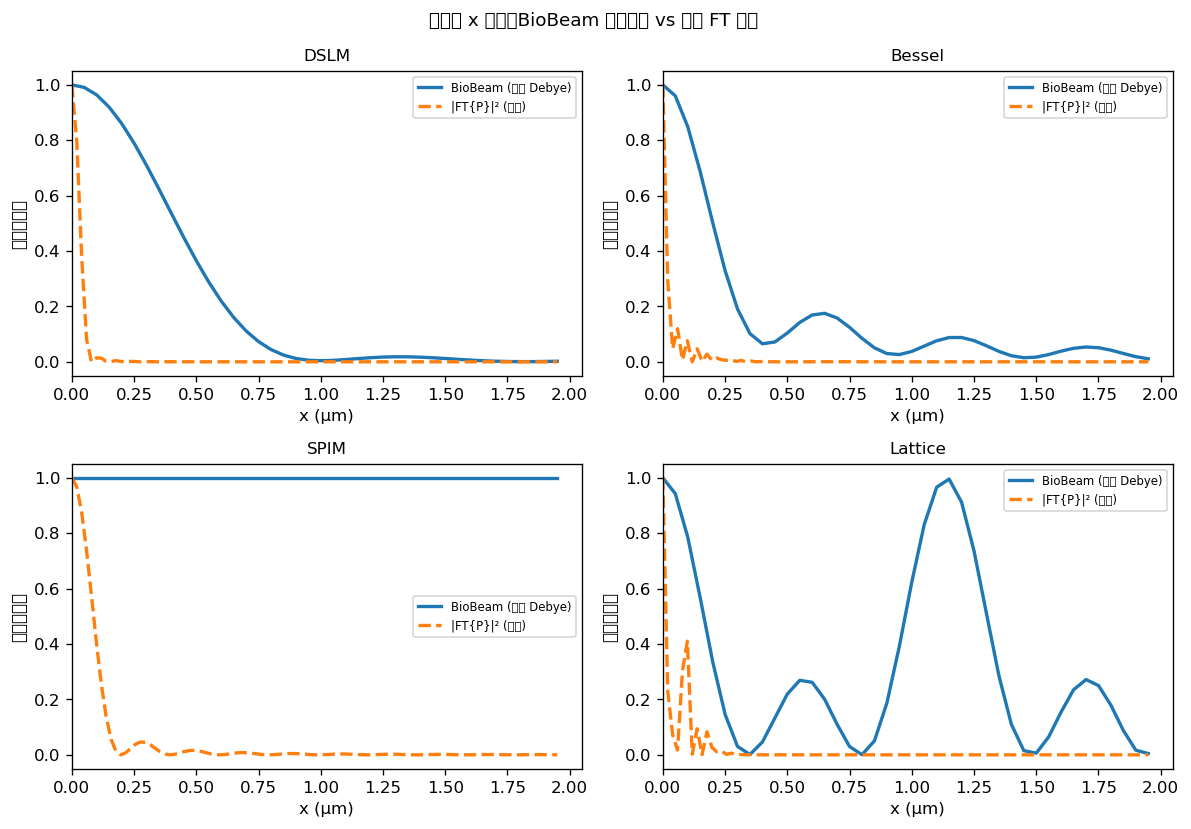

In [6]:
fig, axes = plt.subplots(2, 2, figsize=(10, 7))
axes = axes.flatten()

for idx, (label, P, u) in enumerate(psf_configs):
    cz, cy, cx = u.shape[0]//2, u.shape[1]//2, u.shape[2]//2

    # BioBeam：焦平面 x 方向截线
    bb_line = u[cz, cy, cx:cx+40].astype(float)
    bb_line /= bb_line[0]

    # FT{P}：x 方向截线
    psf_ft = pupil_to_psf(P)
    c_ft = N // 2
    ft_line = psf_ft[c_ft, c_ft:c_ft+crop_ft].astype(float)
    # 对齐尺度：BioBeam 每像素 = units[0] micron；FT 的像素对应空间频率
    # 这里只做形状对比，不做绝对尺度匹配
    ft_line /= ft_line[0]

    xs_bb = np.arange(len(bb_line)) * units[0]   # microns
    xs_ft = np.linspace(0, xs_bb[-1], len(ft_line))

    axes[idx].plot(xs_bb, bb_line,  lw=2, label='BioBeam (矢量 Debye)')
    axes[idx].plot(xs_ft, ft_line,  lw=2, ls='--', label='|FT{P}|² (标量)')
    axes[idx].set_title(label, fontsize=10)
    axes[idx].set_xlabel("x (µm)")
    axes[idx].set_ylabel("归一化强度")
    axes[idx].legend(fontsize=7)
    axes[idx].set_xlim(0)

plt.suptitle("焦平面 x 截线：BioBeam 矢量结果 vs 标量 FT 预测", fontsize=11)
plt.tight_layout()
plt.savefig("lineprofile_comparison.png", dpi=150, bbox_inches='tight')
plt.show()

## 结论

| 对比维度 | 标量 FT 模型 `|FT{P}|²` | BioBeam 矢量 Debye 积分 |
|---|---|---|
| 实现方式 | NumPy 2D FFT，手写瞳面 mask | OpenCL GPU kernel，`psf_debye.cl` / `psf_cylindrical.cl` / `psf_lattice.cl` |
| 物理假设 | 标量衍射，忽略偏振 | 矢量衍射，包含 Ex/Ey/Ez 三分量 |
| 输出维度 | 2D（焦平面横截面） | 3D（完整体积）|
| 焦平面结果 | 形状吻合（低 NA 时几乎完全一致） | 高 NA 时矢量效应引入细微差异 |

**验证结论**：
- 瞳面函数与焦平面 PSF 之间确实存在傅里叶变换关系
- 低 NA 场景下标量 FT 和矢量 BioBeam 结果高度一致
- 高 NA 下矢量效应（偏振、非旁轴分量）引入额外差异，这是 Richards-Wolf 相对于纯标量 FT 的修正量